In [14]:
#Importation des bibliotheques
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split,GridSearchCV
from matplotlib import pyplot as plt
import seaborn as sns



In [15]:
#Chargement du dataset wine
wine=datasets.load_wine()
X=pd.DataFrame(wine.data,columns=wine.feature_names)
Y=pd.Series(wine.target,name="classe")
X.head(),Y.head()

(   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
 0    14.23        1.71  2.43               15.6      127.0           2.80   
 1    13.20        1.78  2.14               11.2      100.0           2.65   
 2    13.16        2.36  2.67               18.6      101.0           2.80   
 3    14.37        1.95  2.50               16.8      113.0           3.85   
 4    13.24        2.59  2.87               21.0      118.0           2.80   
 
    flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
 0        3.06                  0.28             2.29             5.64  1.04   
 1        2.76                  0.26             1.28             4.38  1.05   
 2        3.24                  0.30             2.81             5.68  1.03   
 3        3.49                  0.24             2.18             7.80  0.86   
 4        2.69                  0.39             1.82             4.32  1.04   
 
    od280/od315_of_diluted_wines  proline  
 0  

In [16]:
#Exploration du jeu de données
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [17]:
#Separation train/test
(X_train,X_test,Y_train,Y_test)=train_test_split(X,Y,test_size=0.2,random_state=42)


In [18]:
#Normalisation des données
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


Accuracy: 0.9722222222222222
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.93      0.96        14
           2       0.89      1.00      0.94         8

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.98      0.97      0.97        36



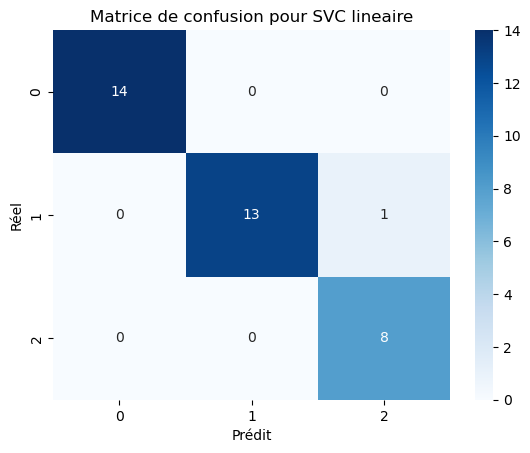

In [22]:
#Entrainement du SVC lineaire
svm_linear=SVC(kernel="linear")
svm_linear.fit(X_train_scaled,Y_train)
#Prédiction pour SVC lineaire
Y_pred_linear=svm_linear.predict(X_test_scaled)
#Evaluation du SVC linear
print("Accuracy:",accuracy_score(Y_test,Y_pred_linear))
print("Classification Report:")
print(classification_report(Y_test,Y_pred_linear))
#Matrice de confusion pour SVC linear
cm_linear=confusion_matrix(Y_test,Y_pred_linear)
sns.heatmap(cm_linear,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pour SVC lineaire")
plt.show()




AAccuracy: 0.9722222222222222
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



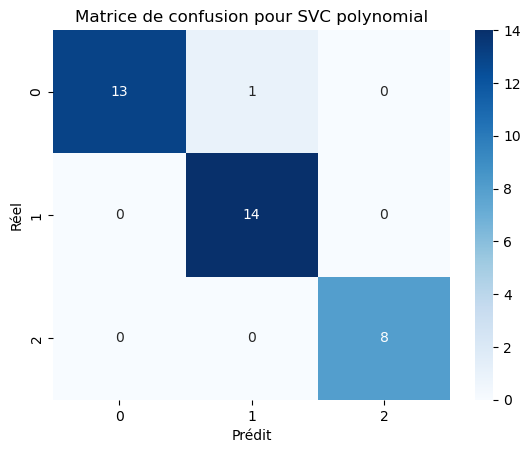

In [24]:
#Entrainement du modele SVC polynomial
svm_poly=SVC(kernel="poly",degree=3)
svm_poly.fit(X_train_scaled,Y_train)
#Prédiction pour SVC polynomial
Y_pred_poly=svm_poly.predict(X_test_scaled)
#Evaluation du SVC polynomial
print("AAccuracy:",accuracy_score(Y_test,Y_pred_poly))
print("Classification report:")
print(classification_report(Y_test,Y_pred_poly))
#Matrice de confusion pour SVC polynomial
cm_poly=confusion_matrix(Y_test,Y_pred_poly)
sns.heatmap(cm_poly,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pour SVC polynomial")
plt.show()

Accuracy: 1.0
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



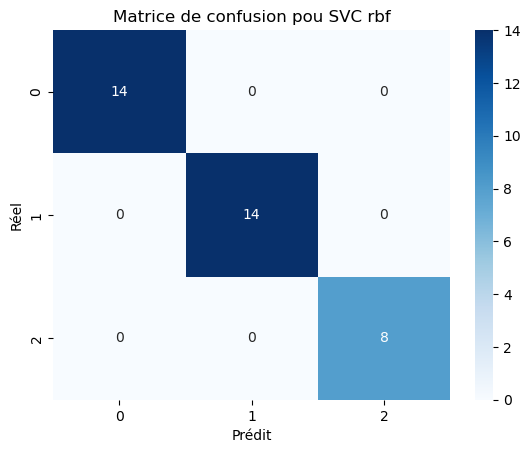

In [26]:
#Entrainement du SVC rbf
svm_rbf=SVC(kernel="rbf")
svm_rbf.fit(X_train_scaled,Y_train)
#Prediction pour SVC rbf
Y_pred_rbf=svm_rbf.predict(X_test_scaled)
#Evaluation pour SVC rbf
print("Accuracy:",accuracy_score(Y_test,Y_pred_rbf))
print("Classification report:")
print(classification_report(Y_test,Y_pred_rbf))
#Matrice de confusion pou SVC rbf
cm_rbf=confusion_matrix(Y_test,Y_pred_rbf)
sns.heatmap(cm_rbf,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pou SVC rbf")
plt.show()


In [30]:
#Application de GridSearchCV
param_grid=[
    {'kernel':['linear'],'C':[0.1,1,10]},
    {'kernel':['poly'],'C':[0.1,1,10],'degree':[2,3,4]},
    {'kernel':['rbf'],'C':[0.1,1,10],'gamma':['scale',0.1,0.01]}
]
grid=GridSearchCV(SVC(),param_grid,cv=5,scoring='accuracy')
grid.fit(X_train_scaled,Y_train)
print("Best parameters:",grid.best_params_)
print("Best CV score:",grid.best_score_)
Y_pred_best=grid.predict(X_test_scaled)
print("Accuracy:",accuracy_score(Y_test,Y_pred_best))


Best parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV score: 0.9788177339901478
Accuracy: 1.0
